In [1]:
import sys
from pathlib import Path
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import ModelConfig, DEFAULT_CONFIG, BATCH_SIZE, NUM_WORKERS
from model import ADModel, create_model, SSLModel, getAttenF
from dataset import create_dataloaders

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <3F789787-FE38-3CE7-8599-064BDD0416EE> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/lib/libtorch_cpu.dylib
  warn(f"Failed to load image Python extension: {e}")


In [2]:
DATASET_NAME = "ADReSSo"

In [3]:
PROJECT_ROOT = script_dir.parent.parent.parent
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-val.csv"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{DATASET_NAME}_merged"
XLSR_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_xlsr_features"
TRAIN_RATIO = 0.8
SAMPLING_RATE = 16000
FEATURE_DIR_NAME = f"{DATASET_NAME}_xlsr_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"{DATASET_NAME}_xlsr_multi_seed"

TRAIN_COLOR = '#2E86AB'
VAL_COLOR = '#A23B72'

In [4]:
MAX_EPOCHS = 200
LEARNING_RATE = 3e-3
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-2
NUM_WORKERS = 4
RANDOM_SEEDS = [21, 42, 84, 168, 336]

In [5]:
if torch.cuda.is_available():
      device = torch.device('cuda')
elif torch.backends.mps.is_available():
      device = torch.device('mps')
else:
      device = torch.device('cpu')

## Step 1: Create Train/Val Split for Address Dataset


In [6]:
from data_split import create_train_val_split

TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir = RAW_AUDIO_DIR,
    train_csv_path = TRAIN_CSV,
    val_csv_path = VAL_CSV,
    feature_dir_name = FEATURE_DIR_NAME,
    train_ratio=TRAIN_RATIO,
    random_seed = 42,
    dataset_name = DATASET_NAME
)

============= ADReSSo Train/Val Split Complete! =============
训练集: 189 样本 (Control: 101, Dementia: 88)
验证集: 48 样本 (Control: 26, Dementia: 22)

训练集CSV 路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/ADReSSo-xlsr-train.csv
验证集CSV 路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/ADReSSo-xlsr-val.csv


## Step 2: Extract XLSR Features


In [7]:
# Import the general-purpose XLSR feature extraction function
from extract_XLSR_feature import extract_xlsr_features_from_csv

# Extract XLSR features using the general function
extract_xlsr_features_from_csv(
    train_csv_path=TRAIN_CSV,
    val_csv_path=VAL_CSV,
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    project_root=PROJECT_ROOT,
    sampling_rate=SAMPLING_RATE,
    device = device
)

Using device: mps
Using original model


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



============= Extracting XLSR features for Train Set =============
189 Audio Files


Extracting Train Set: 100%|██████████| 189/189 [00:00<00:00, 66181.62it/s]



============= Train Set Extraction Complete! =============
Successfully extracted: 0
Already exists (skipped): 189
Errors: 0
Total: 189

============= Extracting XLSR features for Val Set =============
48 Audio Files


Extracting Val Set: 100%|██████████| 48/48 [00:00<00:00, 38304.15it/s]


============= Val Set Extraction Complete! =============
Successfully extracted: 0
Already exists (skipped): 48
Errors: 0
Total: 48

============= All XLSR Feature Extraction Complete! =============
Training Set:   0 extracted, 189 skipped, 189 total
Validation Set: 0 extracted, 48 skipped, 48 total


## Step 4: Create Data Loaders


In [8]:
# Use XLSR features data loader (pre-extracted features)
train_loader, val_loader = create_dataloaders(
    TRAIN_CSV, VAL_CSV, PROJECT_ROOT, 
    BATCH_SIZE, NUM_WORKERS,
    xlsr=True
)

all_results = {'seeds': [], 'val_accs': [], 'val_losses': []}

=============创建训练集（XLSR 特征）=============
✅ 加载完成: 189 个样本
   Control: 101, Dementia: 88

=============创建验证集（XLSR 特征）=============
✅ 加载完成: 48 个样本
   Control: 26, Dementia: 22



## Step 5: Define Training Function and Model


In [9]:
from visualization import plot_training_curves

class MetricsCallback(pl.Callback):
    def __init__(self):
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = []
    
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get('train_loss', 0).item())
        self.train_acc.append(trainer.callback_metrics.get('train_acc', 0).item())
    
    def on_validation_end(self, trainer, pl_module):
        if not trainer.sanity_checking:
            self.epochs.append(trainer.current_epoch)
            self.val_loss.append(trainer.callback_metrics.get('val_loss', 0).item())
            self.val_acc.append(trainer.callback_metrics.get('val_acc', 0).item())

class ADClassifierXLSR(pl.LightningModule):
    def __init__(self):
        super().__init__()
        # Use original ADModel, but configure dim_input=1024 (XLSR feature dimension)
        xlsr_config = ModelConfig(dim_input=1024, dim_hidden=DEFAULT_CONFIG.dim_hidden, dropout=DEFAULT_CONFIG.dropout)
        self.model = ADModel(xlsr_config)
        self.save_hyperparameters()
    def forward(self, x):
        return self.model(x)
    def training_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def train_and_plot(seed, output_dir):
    """Train single seed and visualize"""
    pl.seed_everything(seed)
    seed_dir = output_dir / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    
    model = ADClassifierXLSR()
    metrics_cb = MetricsCallback()
    callbacks = [
        ModelCheckpoint(dirpath=seed_dir, filename='best', monitor='val_acc', mode='max', save_top_k=1),
        EarlyStopping(monitor='val_acc', patience=10, mode='max'),
        metrics_cb
    ]
    
    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
    trainer_kwargs = {'max_epochs': MAX_EPOCHS, 'callbacks': callbacks, 'accelerator': accelerator,
                     'enable_progress_bar': True, 'enable_model_summary': False}
    if accelerator == 'gpu':
        trainer_kwargs['devices'] = 1
    trainer = pl.Trainer(**trainer_kwargs)
    
    trainer.fit(model, train_loader, val_loader)
    
    # Plot training curves
    plot_training_curves(
        epochs=metrics_cb.epochs,
        train_loss=metrics_cb.train_loss,
        val_loss=metrics_cb.val_loss,
        train_acc=metrics_cb.train_acc,
        val_acc=metrics_cb.val_acc,
        train_color=TRAIN_COLOR,
        val_color=VAL_COLOR,
        title_prefix=f'Seed {seed}'
    )

    best_val_acc_val = max(metrics_cb.val_acc)
    best_val_loss = min(metrics_cb.val_loss)
    print(f" Seed {seed} : Val Acc = {best_val_acc_val*100:.2f}%, Val Loss = {best_val_loss:.4f}")
    
    return seed, best_val_acc_val, best_val_loss


### 1st Random Seed = 21


Seed set to 21
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSSo_xlsr_multi_seed/seed_21 exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 16: 100%|██████████| 6/6 [00:00<00:00, 195.25it/s, v_num=267, train_loss_step=0.296, train_acc_step=0.828, val_loss=0.687, val_acc=0.729, train_loss_epoch=0.279, train_acc_epoch=0.884]


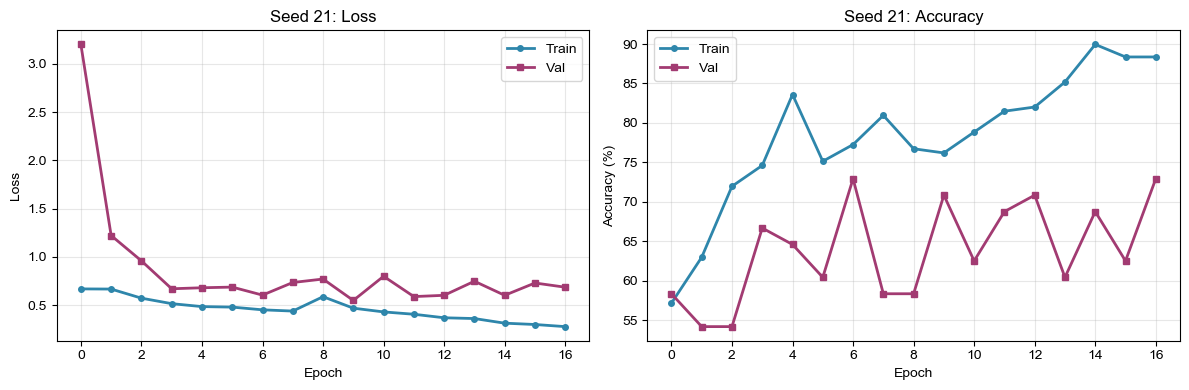

 Seed 21 : Val Acc = 72.92%, Val Loss = 0.5499


In [10]:
# Train Seed 21
seed, val_acc, val_loss = train_and_plot(21, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 2nd Random Seed = 42


Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSSo_xlsr_multi_seed/seed_42 exists and is not empty.


Epoch 22: 100%|██████████| 6/6 [00:00<00:00, 206.61it/s, v_num=268, train_loss_step=0.170, train_acc_step=0.931, val_loss=0.712, val_acc=0.729, train_loss_epoch=0.207, train_acc_epoch=0.937]


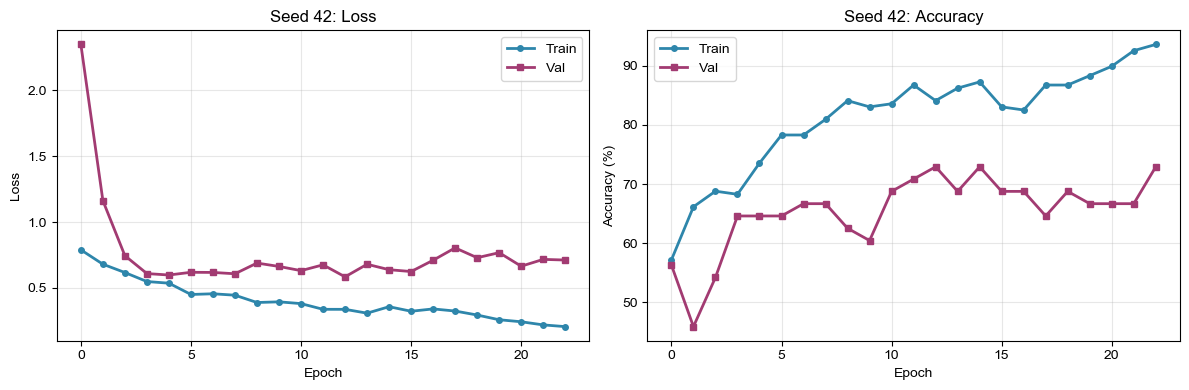

 Seed 42 : Val Acc = 72.92%, Val Loss = 0.5844


In [11]:
# Train Seed 42
seed, val_acc, val_loss = train_and_plot(42, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 3rd Random Seed = 84


Seed set to 84
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSSo_xlsr_multi_seed/seed_84 exists and is not empty.


Epoch 16: 100%|██████████| 6/6 [00:00<00:00, 213.59it/s, v_num=269, train_loss_step=0.176, train_acc_step=0.966, val_loss=0.719, val_acc=0.688, train_loss_epoch=0.278, train_acc_epoch=0.878]


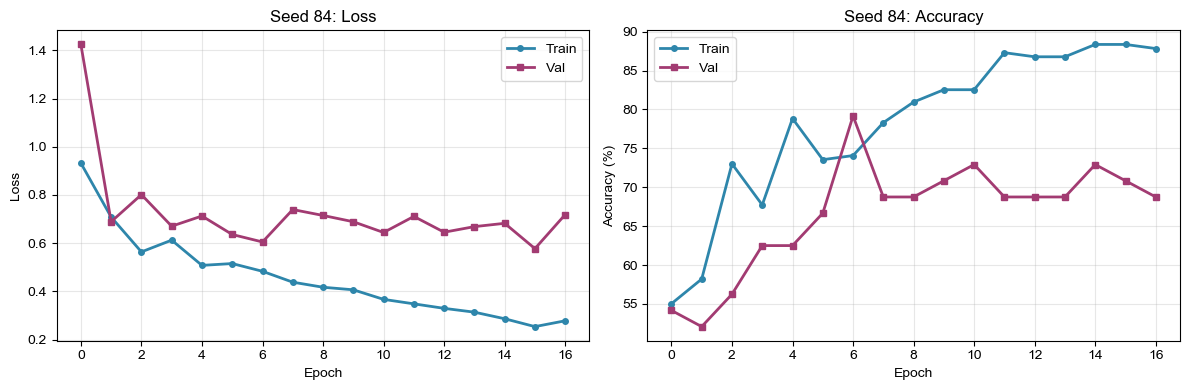

 Seed 84 : Val Acc = 79.17%, Val Loss = 0.5776


In [12]:
# Train Seed 84
seed, val_acc, val_loss = train_and_plot(84, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 4th Random Seed = 168


Seed set to 168
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSSo_xlsr_multi_seed/seed_168 exists and is not empty.


Epoch 19: 100%|██████████| 6/6 [00:00<00:00, 217.90it/s, v_num=270, train_loss_step=0.384, train_acc_step=0.828, val_loss=0.749, val_acc=0.667, train_loss_epoch=0.243, train_acc_epoch=0.921]


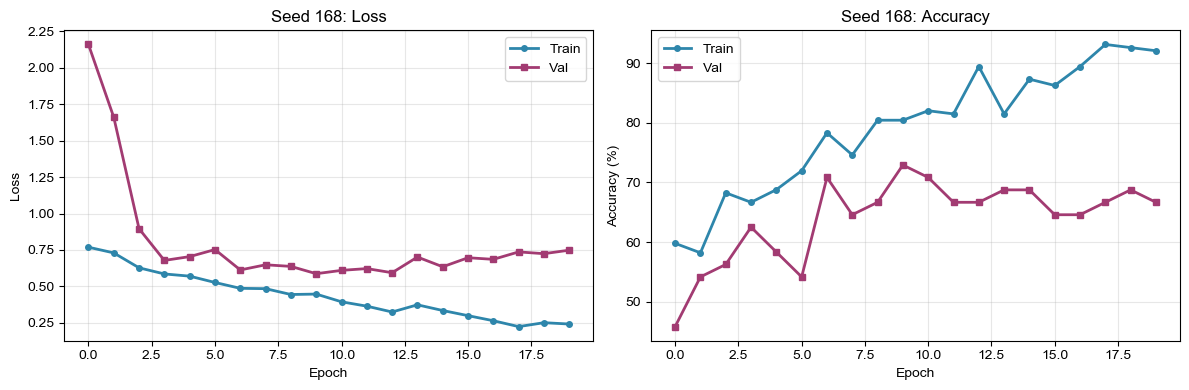

 Seed 168 : Val Acc = 72.92%, Val Loss = 0.5875


In [13]:
# Train Seed 168
seed, val_acc, val_loss = train_and_plot(168, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 5th Random Seed = 336


Seed set to 336
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSSo_xlsr_multi_seed/seed_336 exists and is not empty.


Epoch 15: 100%|██████████| 6/6 [00:00<00:00, 197.37it/s, v_num=271, train_loss_step=0.306, train_acc_step=0.828, val_loss=0.598, val_acc=0.708, train_loss_epoch=0.299, train_acc_epoch=0.831]


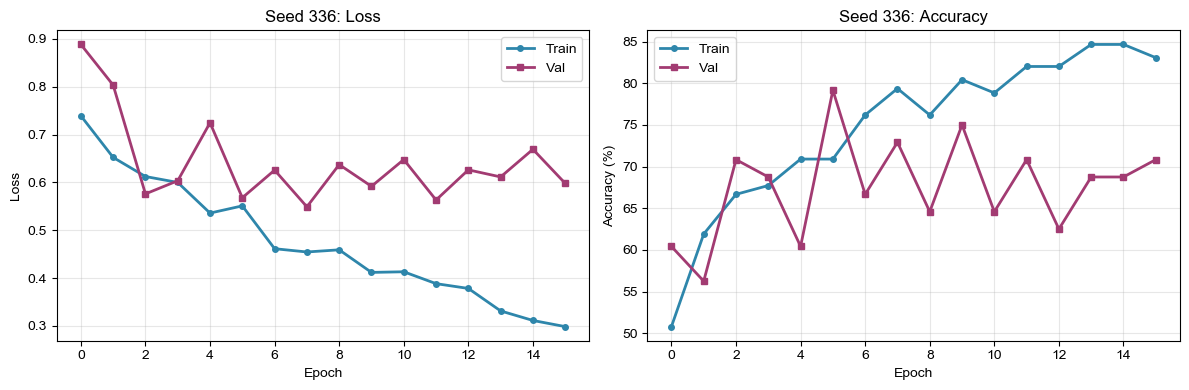

 Seed 336 : Val Acc = 79.17%, Val Loss = 0.5490


In [14]:
# Train Seed 336
seed, val_acc, val_loss = train_and_plot(336, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


In [15]:
# Compare all models
import numpy as np

seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']

# Calculate statistics
mean_acc = np.mean(val_accs)
mean_loss = np.mean(val_losses)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f}")
print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"  Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}")



Mean Validation Accuracy: 75.42%
Mean Validation Loss: 0.5697

Detailed Results:
  Seed 21: Acc=72.92%, Loss=0.5499
  Seed 42: Acc=72.92%, Loss=0.5844
  Seed 84: Acc=79.17%, Loss=0.5776
  Seed 168: Acc=72.92%, Loss=0.5875
  Seed 336: Acc=79.17%, Loss=0.5490
